In [18]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl


## **Precipitation Data**: Import/Mean and uncertainty



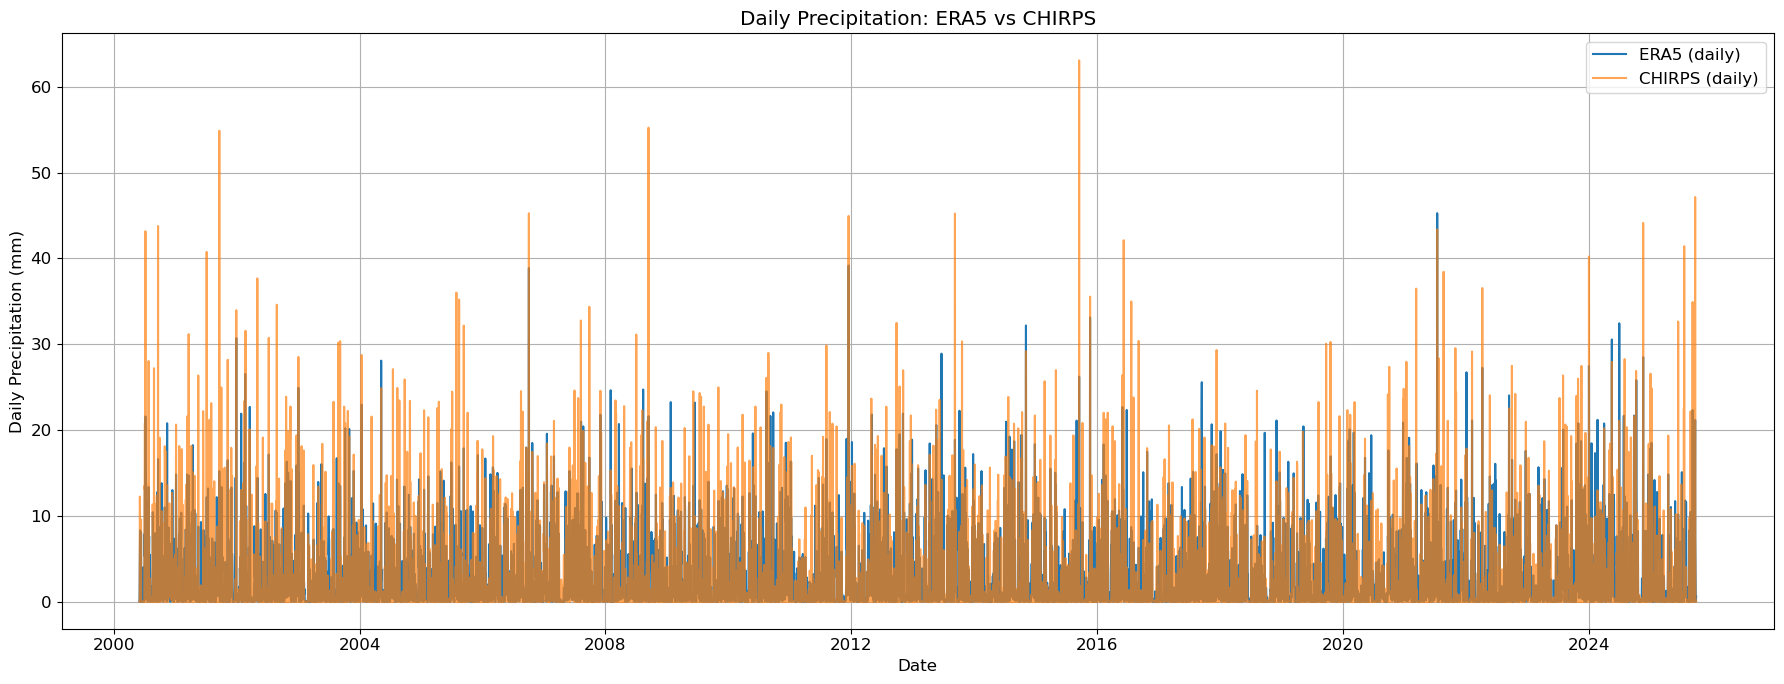

In [19]:
import pandas as pd
import matplotlib.pyplot as plt


#ERA%
era5 = pd.read_csv("ERA5_hourly_precip_1980-2025.csv")

# Convert timestamp
era5['datetime'] = pd.to_datetime(era5['system:index'], format='%Y%m%dT%H')

# Convert hourly precipitation (m) → mm
era5['precip_mm'] = era5['total_precipitation_hourly'] * 1000

# Aggregate to daily totals
era5_daily = era5.groupby(era5['datetime'].dt.date)['precip_mm'].sum().reset_index()
era5_daily['datetime'] = pd.to_datetime(era5_daily['datetime'])

#Chirps
chirps = pd.read_csv("Moselle_CHIRPS_DAILY_precipitation_2000-06-01_2025-10-01.csv")

chirps['datetime'] = pd.to_datetime(chirps['system:index'], format='%Y%m%d')
chirps_daily = chirps[['datetime', 'precipitation']].copy()
chirps_daily.rename(columns={'precipitation': 'precip_mm'}, inplace=True)

#overlapping clip
start = max(era5_daily['datetime'].min(), chirps_daily['datetime'].min())
end   = min(era5_daily['datetime'].max(), chirps_daily['datetime'].max())

era5_daily = era5_daily[(era5_daily['datetime'] >= start) & (era5_daily['datetime'] <= end)]
chirps_daily = chirps_daily[(chirps_daily['datetime'] >= start) & (chirps_daily['datetime'] <= end)]

#plot
plt.figure(figsize=(18,7))
plt.plot(era5_daily['datetime'], era5_daily['precip_mm'], label='ERA5 (daily)')
plt.plot(chirps_daily['datetime'], chirps_daily['precip_mm'], label='CHIRPS (daily)', alpha=0.7)

plt.legend()
plt.xlabel("Date")
plt.ylabel("Daily Precipitation (mm)")
plt.title("Daily Precipitation: ERA5 vs CHIRPS")
plt.grid(True)
plt.rcParams["font.size"] = 12
plt.tight_layout()
plt.show()


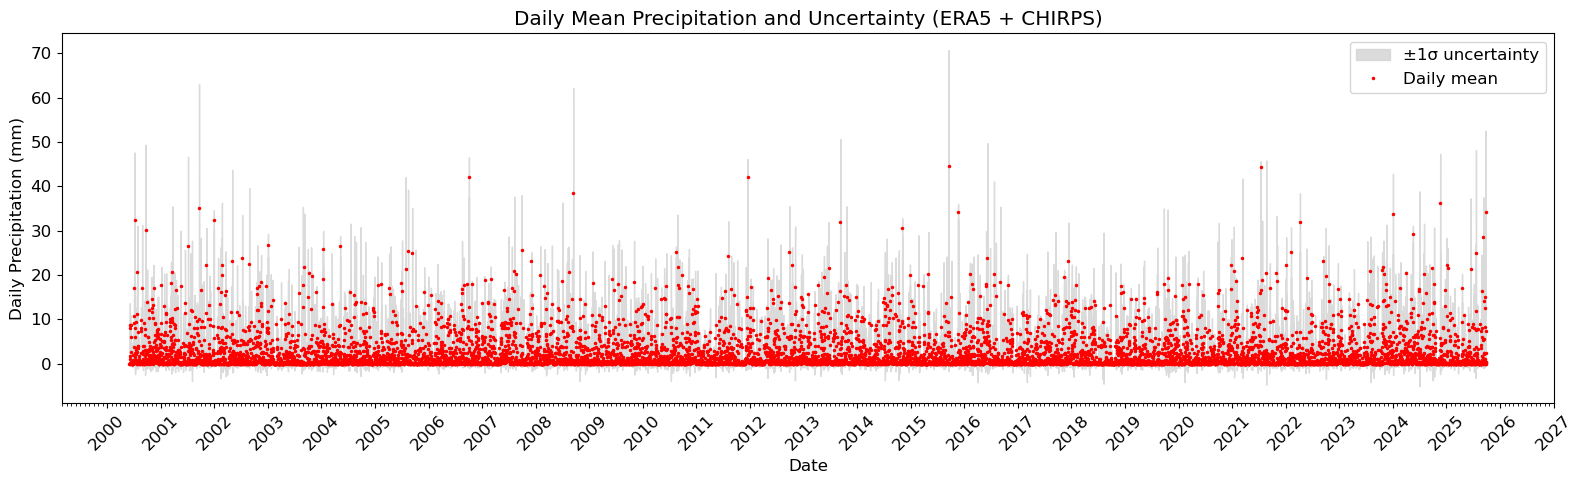

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


fig, ax = plt.subplots(figsize=(16, 5))

# Uncertainty band 
ax.fill_between(
    merged['datetime'],
    merged['mP'] - np.sqrt(merged['vP_adj']),
    merged['mP'] + np.sqrt(merged['vP_adj']),
    color='lightgrey',
    alpha=0.8,
    label='±1σ uncertainty'
)

# Scatterplot of the mean
ax.plot(
    merged['datetime'],
    merged['mP'],
    'r.',
    markersize=3,
    label='Daily mean'
)

# Axis formatting
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())

ax.set_xlabel('Date')
ax.set_ylabel('Daily Precipitation (mm)')
ax.set_title('Daily Mean Precipitation and Uncertainty (ERA5 + CHIRPS)')
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


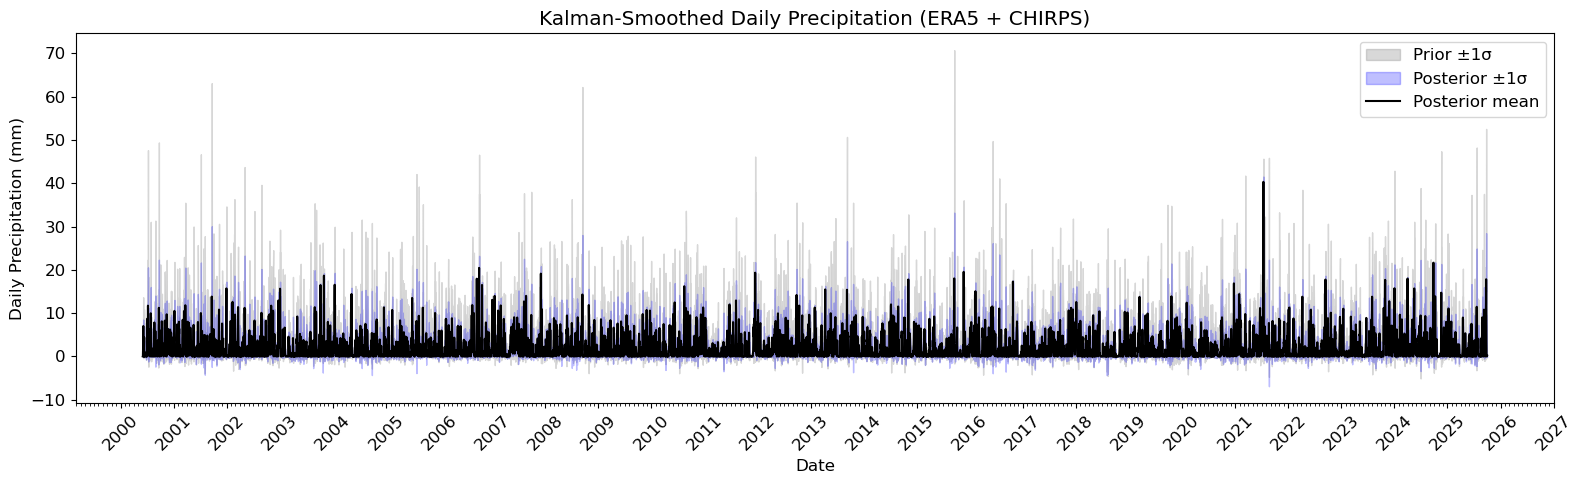

In [21]:
# Add variance floor
eps = 1e-6
vP_safe = np.clip(merged['vP'].to_numpy(), eps, None)
mP = merged['mP'].to_numpy()

def gaussian_product(m1, v1, m2, v2):
    # Safe Gaussian fusion
    vPost = 1.0 / (1.0/v1 + 1.0/v2)
    mPost = vPost * (m1/v1 + m2/v2)
    return mPost, vPost

def smooth_precipitation(mP, vP):
    nt = len(mP)
    
    mFilt = np.zeros(nt)
    vFilt = np.zeros(nt)
    
    mFilt[0] = mP[0]
    vFilt[0] = vP[0]
    
    # Forward pass
    for t in range(1, nt):
        mPred = mFilt[t-1]
        vPred = vFilt[t-1] + vP[t]
        mFilt[t], vFilt[t] = gaussian_product(mPred, vPred, mP[t], vP[t])
    
    # Backward pass
    mSmooth = np.zeros(nt)
    vSmooth = np.zeros(nt)
    mSmooth[-1] = mFilt[-1]
    vSmooth[-1] = vFilt[-1]
    
    for t in reversed(range(nt - 1)):
        mBack = mSmooth[t+1]
        vBack = vSmooth[t+1] + vP[t]
        mSmooth[t], vSmooth[t] = gaussian_product(mFilt[t], vFilt[t], mBack, vBack)
    
    return mSmooth, vSmooth

# Apply smoother with safe variance
mPostP, vPostP = smooth_precipitation(mP, vP_safe)

# Plot posterior
fig, ax = plt.subplots(figsize=(16, 5))

ax.fill_between(
    merged['datetime'],
    mP - np.sqrt(vP),
    mP + np.sqrt(vP),
    color='grey', alpha=0.3, label='Prior ±1σ'
)

ax.fill_between(
    merged['datetime'],
    mPostP - np.sqrt(vPostP),
    mPostP + np.sqrt(vPostP),
    color='blue', alpha=0.25, label='Posterior ±1σ'
)

ax.plot(merged['datetime'], mPostP, 'k-', label='Posterior mean')

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())

ax.set_xlabel('Date')
ax.set_ylabel('Daily Precipitation (mm)')
ax.set_title('Kalman-Smoothed Daily Precipitation (ERA5 + CHIRPS)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

                                      


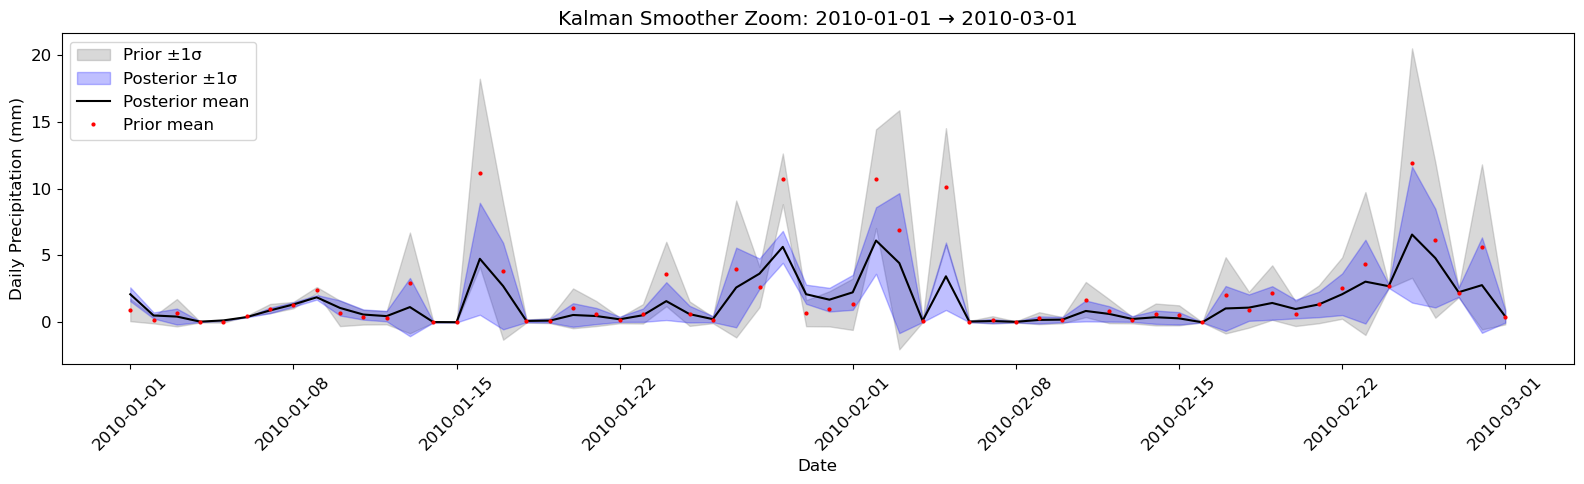

In [23]:
##checking if this is actually good

def plot_zoom(start_date, end_date):
    mask = (merged['datetime'] >= start_date) & (merged['datetime'] <= end_date)

    fig, ax = plt.subplots(figsize=(16, 5))

    # Prior band
    ax.fill_between(
        merged.loc[mask, 'datetime'],
        mP[mask] - np.sqrt(vP_safe[mask]),
        mP[mask] + np.sqrt(vP_safe[mask]),
        color='grey', alpha=0.3, label='Prior ±1σ'
    )

    # Posterior band
    ax.fill_between(
        merged.loc[mask, 'datetime'],
        mPostP[mask] - np.sqrt(vPostP[mask]),
        mPostP[mask] + np.sqrt(vPostP[mask]),
        color='blue', alpha=0.25, label='Posterior ±1σ'
    )

    # Posterior mean
    ax.plot(
        merged.loc[mask, 'datetime'],
        mPostP[mask],
        'k-', label='Posterior mean'
    )

    # Prior mean (scatter)
    ax.plot(
        merged.loc[mask, 'datetime'],
        mP[mask],
        'r.', markersize=4, label='Prior mean'
    )

    ax.set_title(f"Kalman Smoother Zoom: {start_date} → {end_date}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Daily Precipitation (mm)")
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_zoom("2010-01-01", "2010-03-01")


## ** Climate Prediction

SSP1 - 2.6 Positive outlook +0.5%

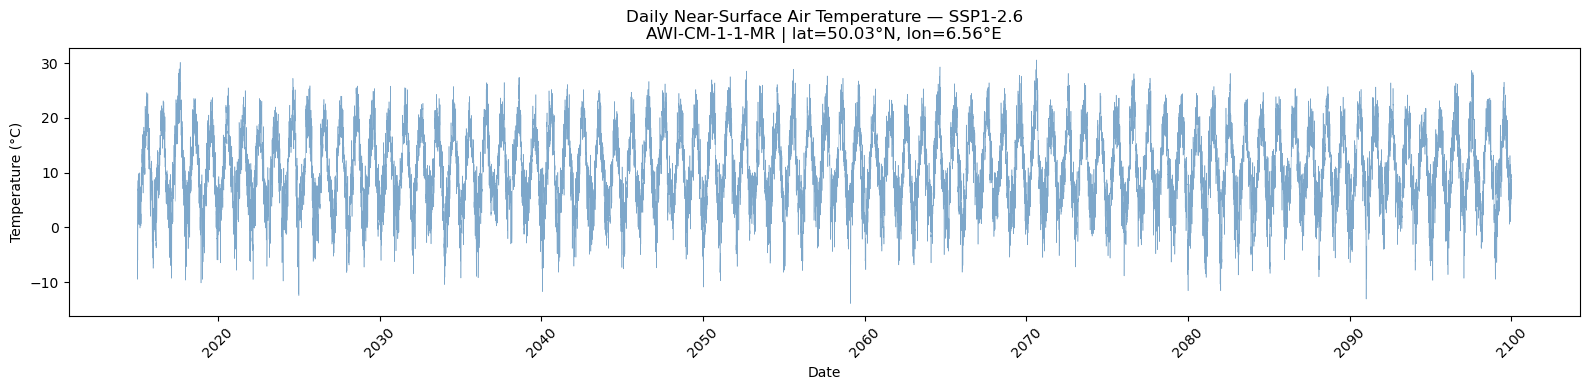

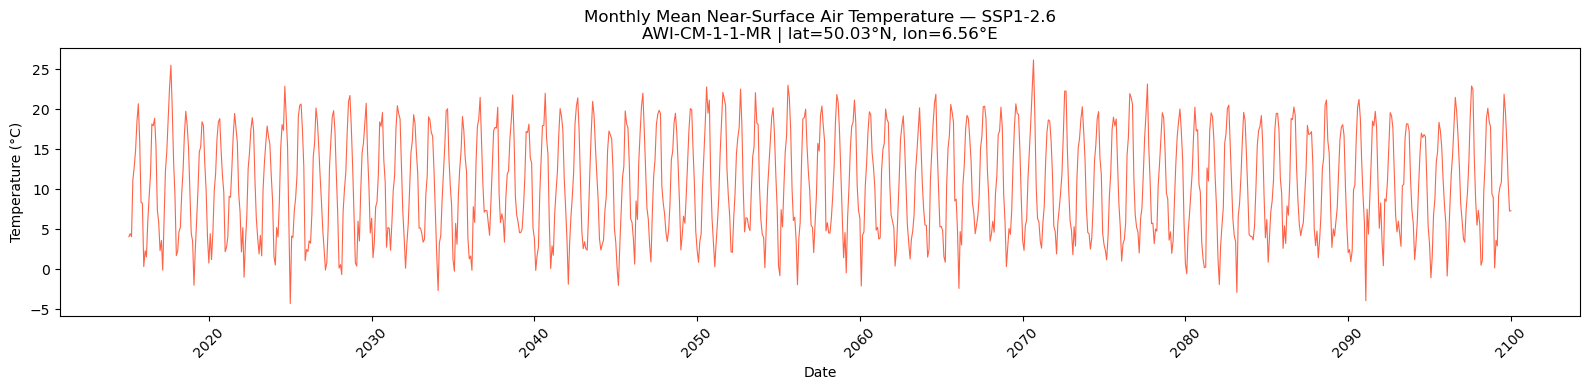

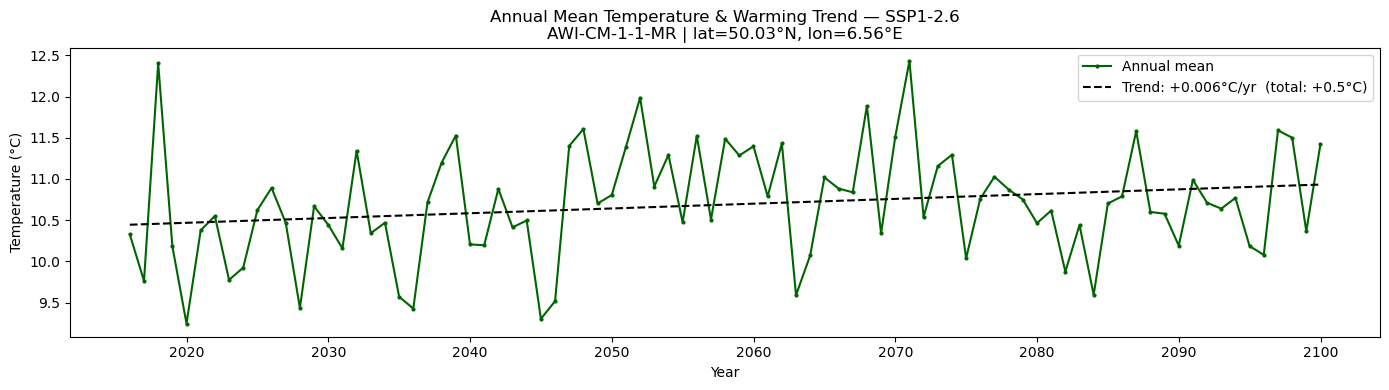


Warming rate: 0.0058 °C/year
Total projected warming 2015→2099: 0.49 °C


In [21]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# ── Load ───────────────────────────────────────────────────────────────────────
ds = xr.open_dataset("SSP1-2.6.nc")

# Extract tas, squeeze out the single lat/lon dims, convert K → °C
tas = ds["tas"].squeeze(["lat", "lon"]) - 273.15
tas.attrs["units"] = "°C"

# ── 1. DAILY plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))

tas.plot(ax=ax, color="steelblue", linewidth=0.4, alpha=0.7)

ax.set_title("Daily Near-Surface Air Temperature — SSP1-2.6\n"
             "AWI-CM-1-1-MR | lat=50.03°N, lon=6.56°E", fontsize=12)
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("daily_tas.png", dpi=150)
plt.show()

# ── 2. MONTHLY plot ────────────────────────────────────────────────────────────
tas_monthly = tas.resample(time="ME").mean()

fig, ax = plt.subplots(figsize=(16, 4))

tas_monthly.plot(ax=ax, color="tomato", linewidth=0.8)

ax.set_title("Monthly Mean Near-Surface Air Temperature — SSP1-2.6\n"
             "AWI-CM-1-1-MR | lat=50.03°N, lon=6.56°E", fontsize=12)
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("monthly_tas.png", dpi=150)
plt.show()

# ── 3. ANNUAL mean + warming trend ────────────────────────────────────────────
tas_annual = tas.resample(time="YE").mean()

years = np.arange(len(tas_annual))
coeffs = np.polyfit(years, tas_annual.values, 1)
trend_line = np.polyval(coeffs, years)
total_warming = trend_line[-1] - trend_line[0]

fig, ax = plt.subplots(figsize=(14, 4))

tas_annual.plot(ax=ax, color="darkgreen", linewidth=1.5,
                marker="o", markersize=2, label="Annual mean")
ax.plot(tas_annual.time, trend_line, "k--", linewidth=1.5,
        label=f"Trend: +{coeffs[0]:.3f}°C/yr  (total: +{total_warming:.1f}°C)")

ax.set_title("Annual Mean Temperature & Warming Trend — SSP1-2.6\n"
             "AWI-CM-1-1-MR | lat=50.03°N, lon=6.56°E", fontsize=12)
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("annual_trend_tas.png", dpi=150)
plt.show()

print(f"\nWarming rate: {coeffs[0]:.4f} °C/year")
print(f"Total projected warming 2015→2099: {total_warming:.2f} °C")

##**Climate Predicitions Moderate 4.5




In [29]:
# ── Load ───────────────────────────────────────────────────────────────────────
ds45 = xr.open_dataset("SSP1-4.5.nc")
print(ds45.data_vars)




Data variables:
    time_bnds  (time, bnds) datetime64[ns] 497kB ...
    lat_bnds   (time, lat, bnds) float64 497kB ...
    lon_bnds   (time, lon, bnds) float64 497kB ...
    tasmax     (time, lat, lon) float32 124kB ...


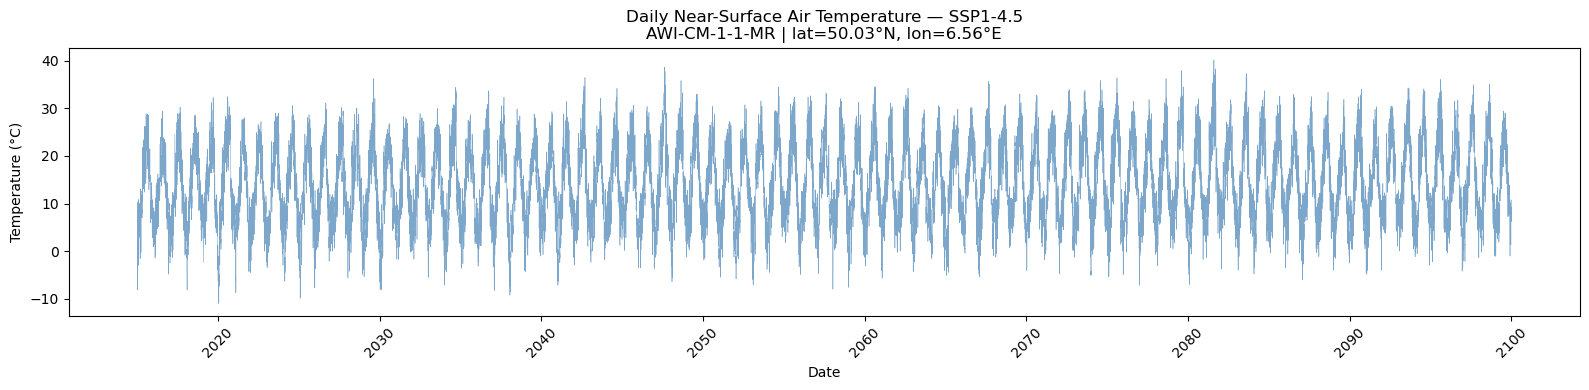

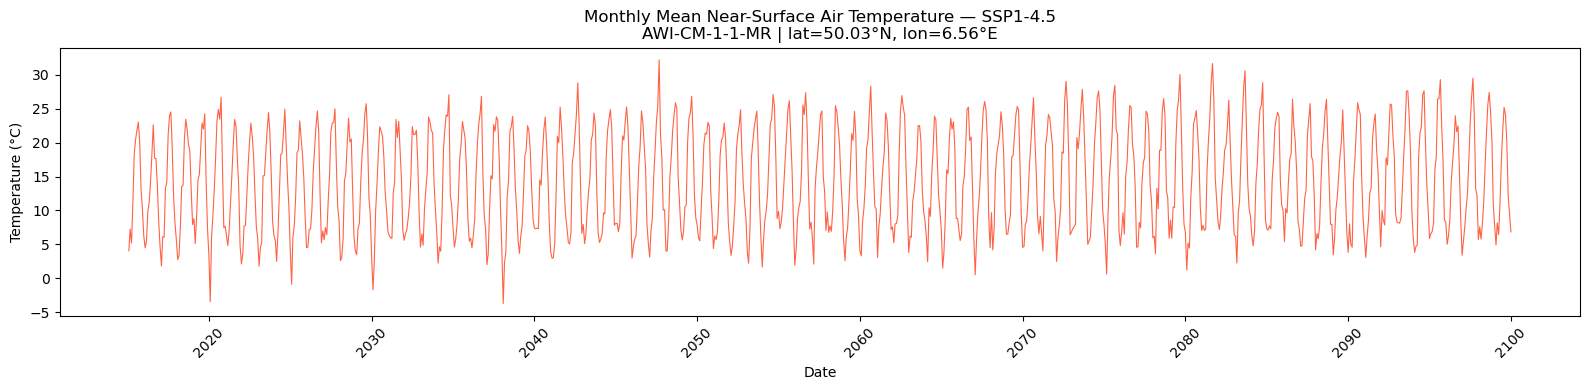

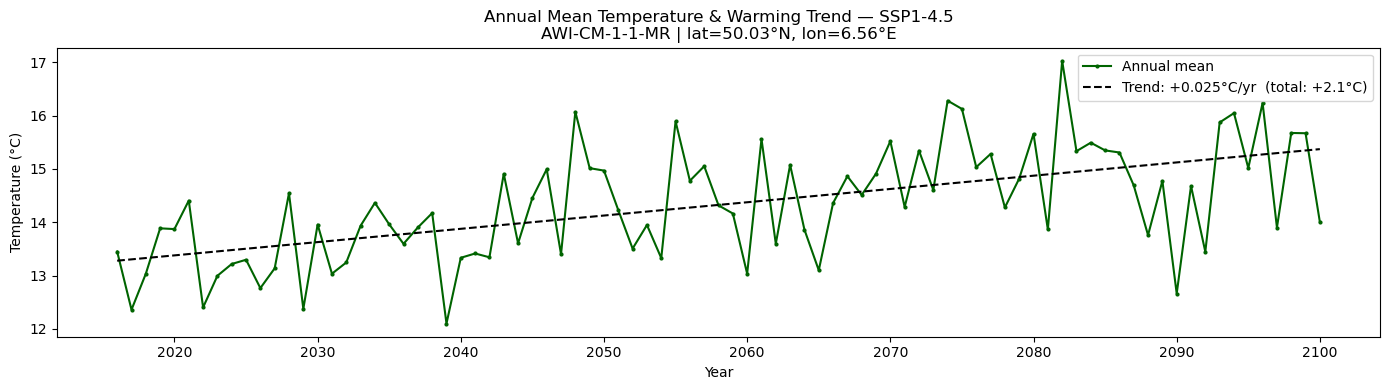


Warming rate (SSP1-4.5): 0.0249


In [33]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# ── Load ───────────────────────────────────────────────────────────────────────
ds45 = xr.open_dataset("SSP1-4.5.nc")

# Use tasmax instead of tas
tas45 = ds45["tasmax"].squeeze(["lat", "lon"]) - 273.15
tas45.attrs["units"] = "°C"

# ── 1. DAILY plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))

tas45.plot(ax=ax, color="steelblue", linewidth=0.4, alpha=0.7)

ax.set_title("Daily Near-Surface Air Temperature — SSP1-4.5\n"
             "AWI-CM-1-1-MR | lat=50.03°N, lon=6.56°E", fontsize=12)
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("daily_tas_45.png", dpi=150)
plt.show()

# ── 2. MONTHLY plot ─────────────────────────────────────────────────────────────
tas45_monthly = tas45.resample(time="ME").mean()

fig, ax = plt.subplots(figsize=(16, 4))

tas45_monthly.plot(ax=ax, color="tomato", linewidth=0.8)

ax.set_title("Monthly Mean Near-Surface Air Temperature — SSP1-4.5\n"
             "AWI-CM-1-1-MR | lat=50.03°N, lon=6.56°E", fontsize=12)
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("monthly_tas_45.png", dpi=150)
plt.show()

# ── 3. ANNUAL mean + warming trend ────────────────────────────────────────────
tas45_annual = tas45.resample(time="YE").mean()

years45 = np.arange(len(tas45_annual))
coeffs45 = np.polyfit(years45, tas45_annual.values, 1)
trend_line45 = np.polyval(coeffs45, years45)
total_warming45 = trend_line45[-1] - trend_line45[0]

fig, ax = plt.subplots(figsize=(14, 4))

tas45_annual.plot(ax=ax, color="darkgreen", linewidth=1.5,
                  marker="o", markersize=2, label="Annual mean")
ax.plot(tas45_annual.time, trend_line45, "k--", linewidth=1.5,
        label=f"Trend: +{coeffs45[0]:.3f}°C/yr  (total: +{total_warming45:.1f}°C)")

ax.set_title("Annual Mean Temperature & Warming Trend — SSP1-4.5\n"
             "AWI-CM-1-1-MR | lat=50.03°N, lon=6.56°E", fontsize=12)
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("annual_trend_tas_45.png", dpi=150)
plt.show()

print(f"\nWarming rate (SSP1-4.5): {coeffs45[0]:.4f}")


*Climate Date - extreme temp increase 8.5 


In [34]:
# ── Load ───────────────────────────────────────────────────────────────────────
ds85 = xr.open_dataset("SSP1-8.5.nc")
print(ds85.data_vars)

Data variables:
    time_bnds  (time, bnds) datetime64[ns] 497kB ...
    lat_bnds   (time, lat, bnds) float64 497kB ...
    lon_bnds   (time, lon, bnds) float64 497kB ...
    tas        (time, lat, lon) float32 124kB ...


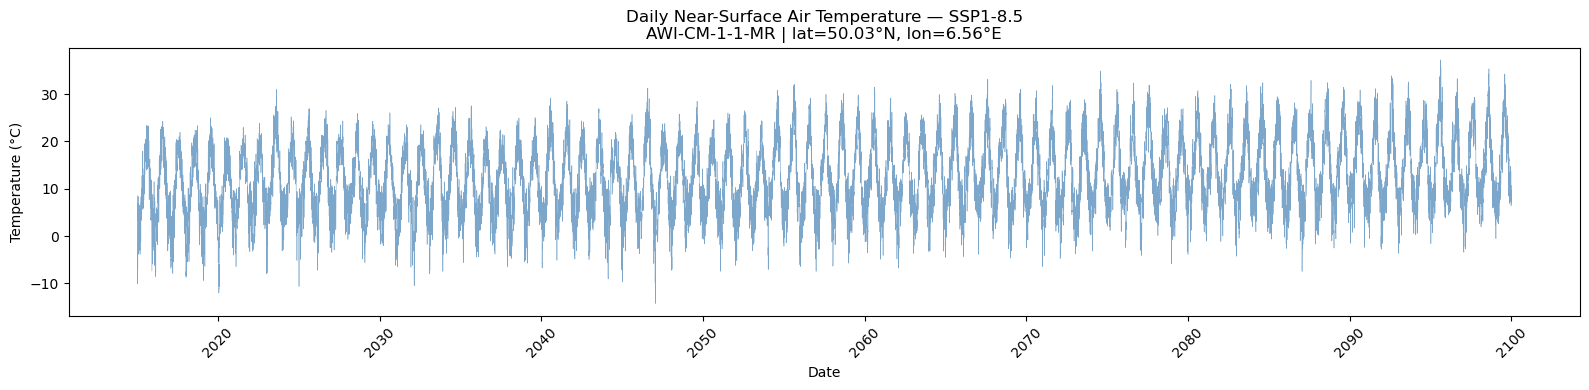

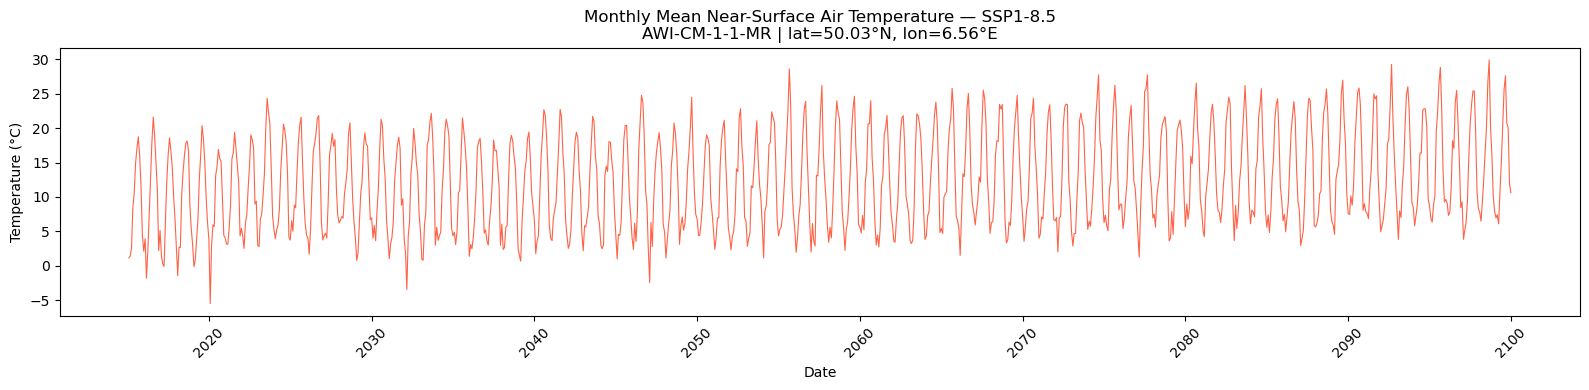

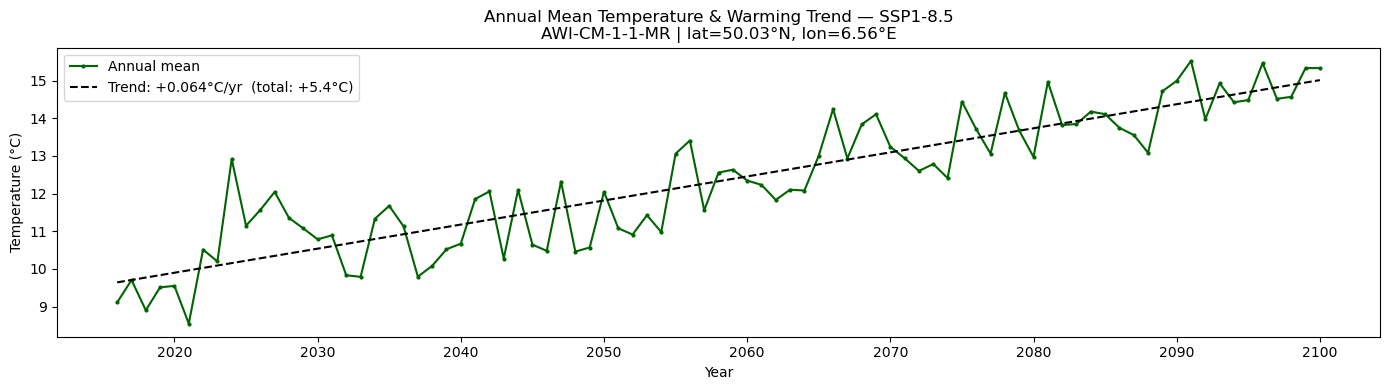


Warming rate (SSP1-8.5): 0.0640 °C/year
Total projected warming 2015→2099 (SSP1-8.5): 5.37 °C


In [37]:


# ── Load ───────────────────────────────────────────────────────────────────────
ds85 = xr.open_dataset("SSP1-8.5.nc")


tas85 = ds85["tas"].squeeze(["lat", "lon"]) - 273.15
tas85.attrs["units"] = "°C"

# ── 1. DAILY plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))

tas85.plot(ax=ax, color="steelblue", linewidth=0.4, alpha=0.7)

ax.set_title("Daily Near-Surface Air Temperature — SSP1-8.5\n"
             "AWI-CM-1-1-MR | lat=50.03°N, lon=6.56°E", fontsize=12)
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("daily_tas_85.png", dpi=150)
plt.show()

# ── 2. MONTHLY plot ─────────────────────────────────────────────────────────────
tas85_monthly = tas85.resample(time="ME").mean()

fig, ax = plt.subplots(figsize=(16, 4))

tas85_monthly.plot(ax=ax, color="tomato", linewidth=0.8)

ax.set_title("Monthly Mean Near-Surface Air Temperature — SSP1-8.5\n"
             "AWI-CM-1-1-MR | lat=50.03°N, lon=6.56°E", fontsize=12)
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("monthly_tas_85.png", dpi=150)
plt.show()

# ── 3. ANNUAL mean + warming trend ────────────────────────────────────────────
tas85_annual = tas85.resample(time="YE").mean()

years85 = np.arange(len(tas85_annual))
coeffs85 = np.polyfit(years85, tas85_annual.values, 1)
trend_line85 = np.polyval(coeffs85, years85)
total_warming85 = trend_line85[-1] - trend_line85[0]

fig, ax = plt.subplots(figsize=(14, 4))

tas85_annual.plot(ax=ax, color="darkgreen", linewidth=1.5,
                  marker="o", markersize=2, label="Annual mean")
ax.plot(tas85_annual.time, trend_line85, "k--", linewidth=1.5,
        label=f"Trend: +{coeffs85[0]:.3f}°C/yr  (total: +{total_warming85:.1f}°C)")

ax.set_title("Annual Mean Temperature & Warming Trend — SSP1-8.5\n"
             "AWI-CM-1-1-MR | lat=50.03°N, lon=6.56°E", fontsize=12)
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("annual_trend_tas_85.png", dpi=150)
plt.show()

print(f"\nWarming rate (SSP1-8.5): {coeffs85[0]:.4f} °C/year")
print(f"Total projected warming 2015→2099 (SSP1-8.5): {total_warming85:.2f} °C")